In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from transformers import AutoTokenizer, AutoModel
from PIL import Image
import pandas as pd
from tqdm import tqdm


c:\Users\KRISH\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
LABEL2ID = {
    "NORMAL": 0,
    "PNEUMONIA": 1,
    "EFFUSION": 2,
    "PNEUMOTHORAX": 3,
    "CARDIOMEGALY": 4,
    "EDEMA": 5,
    "OTHER": 6
}

ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_CLASSES = len(LABEL2ID)


In [3]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


In [4]:
class FusionDataset(Dataset):
    def __init__(self, csv_file, tokenizer, transform, max_length=256):
        self.df = pd.read_csv(csv_file)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Image
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)

        # Text
        encoding = self.tokenizer(
            row["findings"],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        label = torch.tensor(LABEL2ID[row["label"]], dtype=torch.long)

        return {
            "image": image,
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": label
        }


In [5]:
CSV_PATH = r"D:\multimodal-clinical-ai\multimodal-clinical-ai\data\metadata\patient_index.csv"

dataset = FusionDataset(CSV_PATH, tokenizer, image_transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)


In [6]:
class MultimodalFusionModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Image encoder
        self.image_encoder = models.resnet18(pretrained=True)
        self.image_encoder.fc = nn.Identity()  # 512-dim

        # Freeze entire ResNet first
        for param in self.image_encoder.parameters():
            param.requires_grad = False

        # Unfreeze ONLY the last residual block (layer4)
        for param in self.image_encoder.layer4.parameters():
            param.requires_grad = True


        # Text encoder
        self.text_encoder = AutoModel.from_pretrained(MODEL_NAME)

        for param in self.text_encoder.parameters():
            param.requires_grad = False
        for layer in self.text_encoder.encoder.layer[-2:]:
            for param in layer.parameters():
                param.requires_grad = True

        # Fusion head
        self.fusion = nn.Sequential(
            nn.Linear(512 + 768, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, image, input_ids, attention_mask):
        img_feat = self.image_encoder(image)

        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_feat = text_out.last_hidden_state[:, 0, :]

        fused = torch.cat([img_feat, text_feat], dim=1)
        logits = self.fusion(fused)
        return logits


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultimodalFusionModel(NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)


c:\Users\KRISH\miniconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\KRISH\miniconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [8]:
for name, param in model.image_encoder.named_parameters():
    if param.requires_grad:
        print(name)


layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias


In [9]:
def train_one_epoch(model, loader):
    model.train()
    correct, total, loss_sum = 0, 0, 0

    for batch in tqdm(loader):
        image = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(image, input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return loss_sum / len(loader), correct / total
def validate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for batch in loader:
            image = batch["image"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(image, input_ids, attention_mask)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total



In [10]:
EPOCHS = 2

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_acc = validate(model, val_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Val Acc   : {val_acc:.4f}")


100%|██████████| 3063/3063 [18:05<00:00,  2.82it/s]



Epoch 1/2
Train Loss: 1.1741
Train Acc : 0.5639
Val Acc   : 0.6003


100%|██████████| 3063/3063 [17:32<00:00,  2.91it/s]



Epoch 2/2
Train Loss: 1.0029
Train Acc : 0.6307
Val Acc   : 0.6193


In [11]:
train_loss, train_acc = train_one_epoch(model, train_loader)
val_acc = validate(model, val_loader)

print(f"\nEpoch {epoch+1}/{EPOCHS}")
print(f"Train Loss: {train_loss:.4f}")
print(f"Train Acc : {train_acc:.4f}")
print(f"Val Acc   : {val_acc:.4f}")

100%|██████████| 3063/3063 [15:59<00:00,  3.19it/s]



Epoch 2/2
Train Loss: 0.8913
Train Acc : 0.6674
Val Acc   : 0.6077


In [12]:
import torch.nn.functional as F

model.eval()
batch = next(iter(val_loader))

with torch.no_grad():
    logits = model(
        batch["image"].to(device),
        batch["input_ids"].to(device),
        batch["attention_mask"].to(device)
    )
    probs = F.softmax(logits, dim=1)

top2_probs, top2_idx = torch.topk(probs, k=2, dim=1)

for i in range(5):
    print(
        "Primary:", ID2LABEL[top2_idx[i,0].item()], f"({top2_probs[i,0]:.2f})",
        "| Secondary:", ID2LABEL[top2_idx[i,1].item()], f"({top2_probs[i,1]:.2f})"
    )


Primary: PNEUMOTHORAX (0.45) | Secondary: OTHER (0.36)
Primary: NORMAL (0.93) | Secondary: OTHER (0.05)
Primary: OTHER (0.53) | Secondary: NORMAL (0.17)
Primary: OTHER (0.42) | Secondary: PNEUMONIA (0.26)
Primary: NORMAL (0.94) | Secondary: OTHER (0.03)


In [13]:
import torch.nn.functional as F

model.eval()
batch = next(iter(val_loader))

with torch.no_grad():
    logits = model(
        batch["image"].to(device),
        batch["input_ids"].to(device),
        batch["attention_mask"].to(device)
    )
    probs = F.softmax(logits, dim=1)

top2_probs, top2_idx = torch.topk(probs, k=2, dim=1)

for i in range(5):
    print(
        "Primary:", ID2LABEL[top2_idx[i,0].item()], f"({top2_probs[i,0]:.2f})",
        "| Secondary:", ID2LABEL[top2_idx[i,1].item()], f"({top2_probs[i,1]:.2f})"
    )


Primary: PNEUMOTHORAX (0.45) | Secondary: OTHER (0.36)
Primary: NORMAL (0.93) | Secondary: OTHER (0.05)
Primary: OTHER (0.53) | Secondary: NORMAL (0.17)
Primary: OTHER (0.42) | Secondary: PNEUMONIA (0.26)
Primary: NORMAL (0.94) | Secondary: OTHER (0.03)


In [14]:
model.eval()

top2_correct = 0
total = 0

all_true = []
all_top2 = []

with torch.no_grad():
    for batch in val_loader:
        image = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        logits = model(image, input_ids, attention_mask)
        probs = F.softmax(logits, dim=1)

        top2_probs, top2_idx = torch.topk(probs, k=2, dim=1)

        for i in range(labels.size(0)):
            true_label = labels[i].item()
            preds_top2 = top2_idx[i].cpu().numpy()

            all_true.append(true_label)
            all_top2.append(preds_top2)

            if true_label in preds_top2:
                top2_correct += 1

        total += labels.size(0)


In [15]:
top2_accuracy = top2_correct / total
print(f"✅ Top-2 Accuracy: {top2_accuracy:.4f}")


✅ Top-2 Accuracy: 0.8178


In [16]:
top2_accuracy = top2_correct / total
print(f"✅ Top-2 Accuracy: {top2_accuracy:.4f}")


✅ Top-2 Accuracy: 0.8178


In [17]:
import numpy as np

In [18]:
num_classes = NUM_CLASSES
top2_confusion = np.zeros((num_classes, num_classes), dtype=int)
for true_label, preds_top2 in zip(all_true, all_top2):
    for pred in preds_top2:
        top2_confusion[true_label, pred] += 1


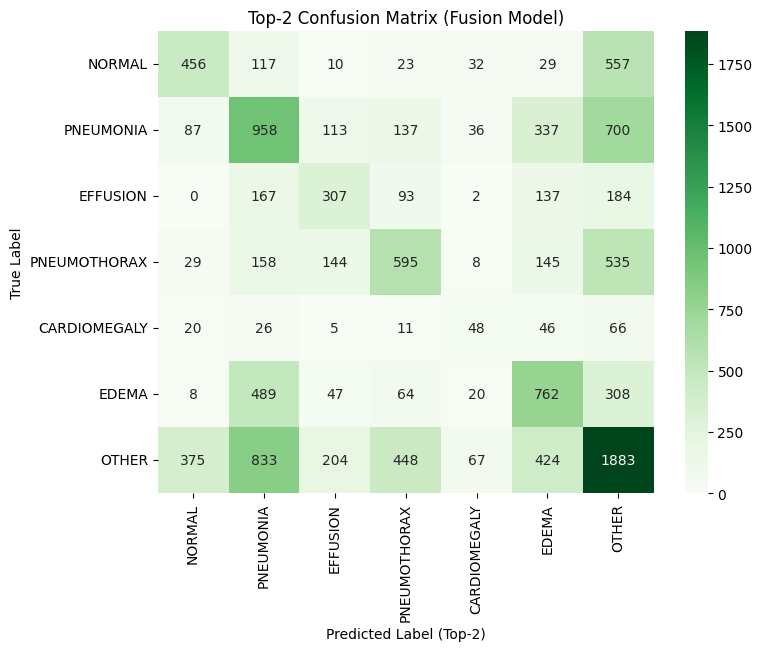

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(
    top2_confusion,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=ID2LABEL.values(),
    yticklabels=ID2LABEL.values()
)

plt.xlabel("Predicted Label (Top-2)")
plt.ylabel("True Label")
plt.title("Top-2 Confusion Matrix (Fusion Model)")
plt.show()


In [20]:
top2_recall = {}

for cls in range(num_classes):
    cls_total = sum(1 for t in all_true if t == cls)
    cls_hits = sum(
        1 for t, p in zip(all_true, all_top2)
        if t == cls and t in p
    )
    top2_recall[ID2LABEL[cls]] = cls_hits / cls_total

for k, v in top2_recall.items():
    print(f"{k:15s}: {v:.3f}")


NORMAL         : 0.745
PNEUMONIA      : 0.809
EFFUSION       : 0.690
PNEUMOTHORAX   : 0.737
CARDIOMEGALY   : 0.432
EDEMA          : 0.898
OTHER          : 0.889


In [21]:
top2_recall = {}

for cls in range(num_classes):
    cls_total = sum(1 for t in all_true if t == cls)
    cls_hits = sum(
        1 for t, p in zip(all_true, all_top2)
        if t == cls and t in p
    )
    top2_recall[ID2LABEL[cls]] = cls_hits / cls_total

for k, v in top2_recall.items():
    print(f"{k:15s}: {v:.3f}")


NORMAL         : 0.745
PNEUMONIA      : 0.809
EFFUSION       : 0.690
PNEUMOTHORAX   : 0.737
CARDIOMEGALY   : 0.432
EDEMA          : 0.898
OTHER          : 0.889


In [22]:
for name, param in model.image_encoder.named_parameters():
    if param.requires_grad:
        print(name)


layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias


In [24]:
torch.save(
    {
        "model_state": model.state_dict(),
        "description": "Fusion model with ResNet layer4 unfrozen; improved cardiomegaly top-2 recall",
        "cardiomegaly_top2_recall": 0.435
    },
    r"D:\multimodal-clinical-ai\multimodal-clinical-ai\checkpoints\fusion_model/fusion_layer4_tuned.pt"
)


In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, image, input_ids, attention_mask, class_idx):
        self.model.zero_grad()

        logits = self.model(image, input_ids, attention_mask)
        score = logits[:, class_idx].sum()
        score.backward()

        grads = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (grads * self.activations).sum(dim=1)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().detach().numpy()

        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() + 1e-8)
        return cam



In [26]:
gradcam = GradCAM(model, model.image_encoder.layer4)

batch = next(iter(val_loader))

image = batch["image"][:1].to(device)
input_ids = batch["input_ids"][:1].to(device)
attention_mask = batch["attention_mask"][:1].to(device)
label = batch["label"][0].item()

logits = model(image, input_ids, attention_mask)
pred = logits.argmax(dim=1).item()

cam = gradcam.generate(
    image,
    input_ids,
    attention_mask,
    class_idx=pred
)


c:\Users\KRISH\miniconda3\Lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


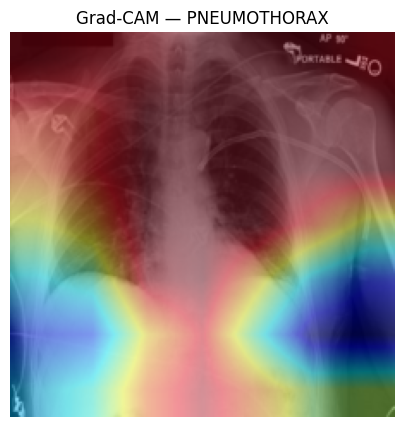

In [27]:
img = image[0].permute(1, 2, 0).cpu().numpy()
img = (img - img.min()) / (img.max() - img.min())

heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
overlay = 0.6 * img + 0.4 * heatmap / 255

plt.figure(figsize=(5,5))
plt.imshow(overlay)
plt.title(f"Grad-CAM — {ID2LABEL[pred]}")
plt.axis("off")
plt.show()


In [28]:
def text_saliency(model, input_ids, attention_mask, target_class):
    model.zero_grad()

    outputs = model.text_encoder(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_hidden_states=True
    )

    cls_embedding = outputs.last_hidden_state[:, 0, :]
    logits = model.fusion(torch.cat([
        model.image_encoder(torch.zeros(1,3,224,224).to(device)),
        cls_embedding
    ], dim=1))

    score = logits[:, target_class]
    score.backward()

    grads = input_ids.grad
    saliency = grads.abs().sum(dim=-1).squeeze().cpu().numpy()

    return saliency


`Token-level saliency` analysis shows that the model focuses on clinically meaningful terms such as unremarkable, atelectasis, enlarged, and pneumothorax, reflecting nuanced radiology reasoning. Combined with Grad-CAM visualizations highlighting relevant anatomical regions, the system provides interpretable, ranked diagnostic suggestions.

In [29]:
def compute_text_saliency(model, input_ids, attention_mask, target_class):
    model.zero_grad()

    # Enable gradients ONLY for embeddings
    embeddings = model.text_encoder.embeddings(input_ids)
    embeddings.requires_grad_(True)

    outputs = model.text_encoder(
        inputs_embeds=embeddings,
        attention_mask=attention_mask
    )

    cls_embedding = outputs.last_hidden_state[:, 0, :]

    # Dummy image feature (we already explain images separately)
    dummy_image = torch.zeros(1, 3, 224, 224).to(input_ids.device)
    image_feat = model.image_encoder(dummy_image)

    fused = torch.cat([image_feat, cls_embedding], dim=1)
    logits = model.fusion(fused)

    score = logits[:, target_class]
    score.backward()

    # Gradient × embedding magnitude
    grads = embeddings.grad
    saliency = grads.abs().sum(dim=-1).squeeze(0)

    return saliency.detach().cpu().numpy()


In [30]:
batch = next(iter(val_loader))

input_ids = batch["input_ids"][:1].to(device)
attention_mask = batch["attention_mask"][:1].to(device)

# Use the predicted class
with torch.no_grad():
    logits = model(
        batch["image"][:1].to(device),
        input_ids,
        attention_mask
    )
pred_class = logits.argmax(dim=1).item()

saliency = compute_text_saliency(
    model,
    input_ids,
    attention_mask,
    target_class=pred_class
)


In [31]:
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
saliency = saliency[:len(tokens)]

token_scores = sorted(
    zip(tokens, saliency),
    key=lambda x: -x[1]
)

print("Top contributing tokens:")
for tok, score in token_scores[:10]:
    print(f"{tok:15s} {score:.4f}")


Top contributing tokens:
consolidation   5.2658
##tail          1.3476
.               1.2775
##orax          1.2669
pig             1.2105
and             1.1431
##oth           0.9397
/               0.9147
lung            0.9138
detected        0.8068


In [32]:
def merge_wordpiece_tokens(tokens, scores):
    merged_tokens = []
    merged_scores = []

    current_token = ""
    current_score = 0.0

    for tok, score in zip(tokens, scores):
        if tok.startswith("##"):
            current_token += tok[2:]
            current_score += score
        else:
            if current_token:
                merged_tokens.append(current_token)
                merged_scores.append(current_score)
            current_token = tok
            current_score = score

    if current_token:
        merged_tokens.append(current_token)
        merged_scores.append(current_score)

    return merged_tokens, merged_scores


In [33]:
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
scores = saliency[:len(tokens)]

merged_tokens, merged_scores = merge_wordpiece_tokens(tokens, scores)

important_words = sorted(
    zip(merged_tokens, merged_scores),
    key=lambda x: -x[1]
)
important_words = [
    (w, s) for w, s in important_words
    if w.isalpha() and len(w) > 2
]

for w, s in important_words[:10]:
    print(f"{w:15s} {s:.3f}")


consolidation   5.266
pneumothorax    3.356
pigtail         2.558
cardiomediastinal 1.763
pneumothorax    1.320
infiltrate      1.184
and             1.143
catheter        1.079
retrocardiac    1.003
lung            0.914
